In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content


drive  sample_data


In [ ]:
!ls /content/drive/MyDrive


 20260731_204125.jpg
 23103025_Shwetakumari
'AIMLDS (1).gdoc'
 AIMLDS.gdoc
'AI Summer Camp .gform'
 aptos2019-blindness-detection.zip
'Assignment 2.gdoc'
'Boolean Expression_K MAP.gdoc'
'cgpa 1st sem (1).pdf'
'Chapter 1 - Computer Networks and the Internet - CN CSN4003.gslides'
 Classroom
 COA_ALLROUNDER_SHWETA_KUMARI_23103025_FINAL.pdf
 COA_ALLROUNDER_SHWETA_KUMARI_23103025.pdf
 COA_APC_SHWEAT_KUMARI_23203025.pdf
 COA_APC_SHWETA_KUMARI_FINAL_23103025.pdf
'Colab Notebooks'
 dataAcquisuitionPreproce2.gdoc
 DSC01878.JPG
 Gender_Sensitivity.gslides
 gender_sensitivity_presentation.html
 IMG_20200428_185718.jpg
 IMG-20220129-WA0002.jpg
 IMG-20220129-WA0003.jpg
 IMG_20220729_212324.jpg
 IMG-20231119-WA0010.jpg
 IMG_20240806_104008.jpg
 IMG-20240806-WA0010.jpg
 Internship.pdf
'jee mains 2023 (1).pdf'
'jee mains 2023.pdf'
'John E. Hopcroft, Rajeev Motwani, Jeffrey D. Ullman-Introduction to Automata Theory, Languages, and Computations-Prentice Hall (2006).gdoc'
 JR_23103025_Shweta_kumari.pdf
'

In [ ]:
!cp "/content/drive/MyDrive/aptos2019-blindness-detection.zip" /content/


In [ ]:
!ls -lh /content


total 9.6G
-rw------- 1 root root 9.6G Aug 28 15:39 aptos2019-blindness-detection.zip
drwx------ 5 root root 4.0K Aug 28 15:34 drive
drwxr-xr-x 1 root root 4.0K Aug 24 13:28 sample_data


In [ ]:
!unzip aptos2019-blindness-detection.zip -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/test_images/51323e9d2070.png  
  inflating: /content/test_images/515675001b9e.png  
  inflating: /content/test_images/515877da2def.png  
  inflating: /content/test_images/5168ddccea88.png  
  inflating: /content/test_images/5172c056a687.png  
  inflating: /content/test_images/5177461f5339.png  
  inflating: /content/test_images/51910bcb980d.png  
  inflating: /content/test_images/51a3e9b6a1c0.png  
  inflating: /content/test_images/51bbd82feec8.png  
  inflating: /content/test_images/51de5fb8eccd.png  
  inflating: /content/test_images/51e88694c81f.png  
  inflating: /content/test_images/51f0bf8f1544.png  
  inflating: /content/test_images/51f57fb32840.png  
  inflating: /content/test_images/51fa42dc1415.png  
  inflating: /content/test_images/5276ab33b7b0.png  
  inflating: /content/test_images/52a353760f72.png  
  inflating: /content/test_images/531937254e73.png  
  inflating: /content/test_images/5325b1c22c61.p

In [ ]:
!ls /content


aptos2019-blindness-detection.zip  sample_submission.csv  train.csv
drive				   test.csv		  train_images
sample_data			   test_images


In [ ]:
import os
print(os.path.exists("/content/train_images"))
print(os.path.exists("/content/test_images"))
print(os.path.exists("/content/train.csv"))
print(os.path.exists("/content/test.csv"))


True
True
True
True


In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)

TF version: 2.20.0


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/train.csv")
train_df["id_code"] = train_df["id_code"] + ".png"
train_df["diagnosis"] = train_df["diagnosis"].astype(str)

train_df.head()



,id_code,diagnosis
0,000c1434d8d7.png,2
1,001639a390f0.png,4
2,0024cdab0c1e.png,1
3,002c21358ce6.png,0
4,005b95c28852.png,0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np

datagen = ImageDataGenerator(
    validation_split=0.2
)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="/content/train_images",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="/content/train_images",
    x_col="id_code",
    y_col="diagnosis",
    target_size=(224,224),
    batch_size=16,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Found 2930 validated image filenames belonging to 5 classes.
Found 732 validated image filenames belonging to 5 classes.
Class weights: {0: np.float64(0.3991825613079019), 1: np.float64(2.0), 2: np.float64(0.7532133676092545), 3: np.float64(3.7806451612903227), 4: np.float64(2.483050847457627)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
output = Dense(5, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 1,660,773 (6.34 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_dr_model.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 489s 2s/step - accuracy: 0.6020 - loss: 1.2582 - val_accuracy: 0.6243 - val_loss: 0.8565
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.7297 - loss: 0.9180 - val_accuracy: 0.7555 - val_loss: 0.6484
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 490s 3s/step - accuracy: 0.7662 - loss: 0.7867 - val_accuracy: 0.7541 - val_loss: 0.6348
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 441s 2s/step - accuracy: 0.7966 - loss: 0.6884 - val_accuracy: 0.7514 - val_loss: 0.6515
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 499s 3s/step - accuracy: 0.8164 - loss: 0.6165 - val_accuracy: 0.7623 - val_loss: 0.6206
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 448s 2s/step - accuracy: 0.8461 - loss: 0.5363 - val_accuracy: 0.7828 - val_loss: 0.6030
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 440s 2s/step - accuracy: 0.8608 - loss: 0.5133 - val_accuracy: 0.7582 - val_loss: 0.6232
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 439s 2s/step - accuracy: 0.8696 - loss: 0.4442 - val_accu

In [ ]:
from tensorflow.keras.models import load_model

# Load the best saved model from Drive
model = load_model('/content/drive/MyDrive/best_dr_model.keras')

# Evaluate on validation data to get the official accuracy number
loss, accuracy = model.evaluate(val_gen)
print(f"Validation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.7828 - loss: 0.6030
Validation Accuracy: 78.28%
Validation Loss: 0.6030


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
val_gen.reset()
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names (adjust based on your actual class labels)
class_names = list(val_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

46/46 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       337
           1       0.57      0.70      0.63        77
           2       0.83      0.60      0.69       221
           3       0.36      0.55      0.44        38
           4       0.46      0.64      0.54        59

    accuracy                           0.78       732
   macro avg       0.64      0.69      0.65       732
weighted avg       0.81      0.78      0.79       732



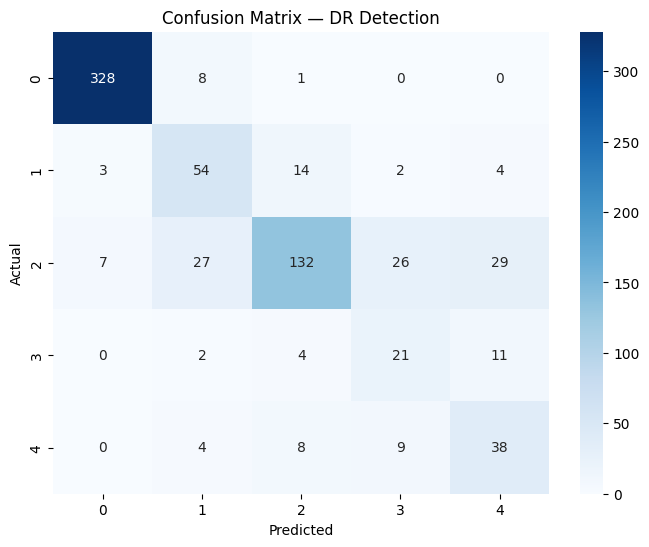

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — DR Detection')
plt.savefig('/content/drive/MyDrive/confusion_matrix.png')  # saves for later use
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step


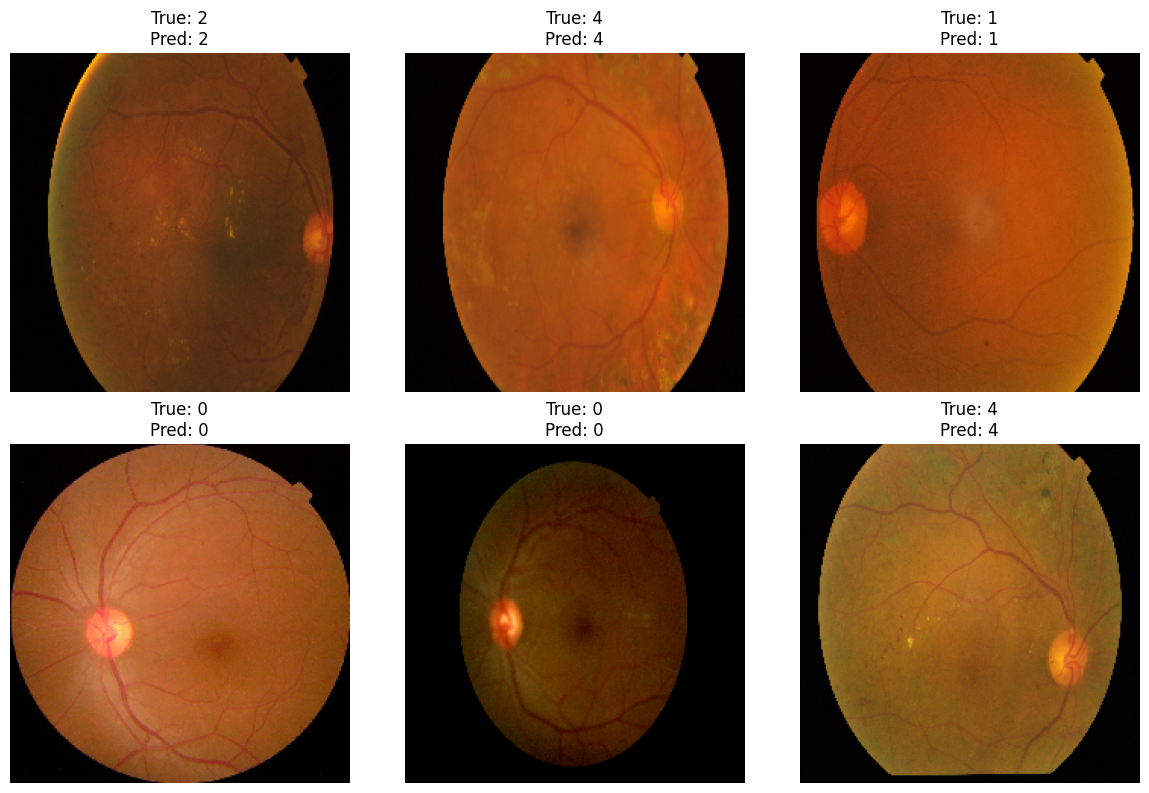

In [27]:
val_gen.reset()
images, labels = next(val_gen)
preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1) if labels.ndim > 1 else labels

def to_displayable(img):
    img = img.astype(np.float32)
    img_min, img_max = img.min(), img.max()
    if img_max - img_min > 0:
        img = (img - img_min) / (img_max - img_min)
    return np.clip(img, 0, 1)

plt.figure(figsize=(12,8))
for i in range(min(6, len(images))):
    plt.subplot(2,3,i+1)
    plt.imshow(to_displayable(images[i]))
    plt.title(f"True: {class_names[true_classes[i]]}\nPred: {class_names[pred_classes[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()